Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [2]:
# 1. Беремо тільки колонку Passengers і перетворюємо в float32 ndarray
passengers = df['Passengers'].values.astype('float32')

print(type(passengers))
print(passengers[:5])        # мають бути: [112. 118. 132. 129. 121.]

<class 'numpy.ndarray'>
[112. 118. 132. 129. 121.]


Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [3]:
# 2. Розбиття на train / val (по часу, БЕЗ перемішування!)
train_size = int(len(passengers) * 0.67)

train_data = passengers[:train_size]
val_data   = passengers[train_size:]

print("Усього точок:", len(passengers))
print("Train size:", len(train_data))
print("Val size:", len(val_data))

print("\nПерші 5 train:", train_data[:5])
print("Перші 5 val:", val_data[:5])

Усього точок: 144
Train size: 96
Val size: 48

Перші 5 train: [112. 118. 132. 129. 121.]
Перші 5 val: [315. 301. 356. 348. 355.]


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [5]:
import torch

In [6]:
def create_dataset(dataset: np.ndarray, lookback: int):
    """
    dataset  – одномірний numpy-масив часовго ряду (float32),
    lookback – скільки попередніх кроків беремо як ознаки.

    Повертає:
        X – тензор форми (n_samples, lookback)
        y – тензор форми (n_samples, 1)
    """
    X, y = [], []
    for i in range(len(dataset) - lookback):
        X.append(dataset[i : i + lookback])   # попередні lookback значень
        y.append(dataset[i + lookback])       # наступне значення

    X = torch.tensor(np.array(X, dtype='float32'))          # (N, lookback)
    y = torch.tensor(np.array(y, dtype='float32')).view(-1, 1)  # (N, 1)
    return X, y

# Перевірка для lookback = 1, як у завданні:
lookback = 1
X_train, y_train = create_dataset(train_data, lookback)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("\nПерші 5 X_train:\n", X_train[:5])
print("\nПерші 5 y_train:\n", y_train[:5])


X_train shape: torch.Size([95, 1])
y_train shape: torch.Size([95, 1])

Перші 5 X_train:
 tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])

Перші 5 y_train:
 tensor([[118.],
        [132.],
        [129.],
        [121.],
        [135.]])


In [10]:
lookback = 1
X_train, y_train = create_dataset(train_data, lookback=lookback)
X_test, y_test = create_dataset(val_data, lookback=lookback)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [11]:
import torch
import torch.nn as nn

class AirModel(nn.Module):
    def __init__(self, hidden_size: int = 50, num_layers: int = 1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM шар
        self.lstm = nn.LSTM(
            input_size=1,          # одна ознака на кроці (кількість пасажирів)
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True       # форма (batch, seq_len, input_size)
        )

        # Лінійний шар для перетворення виходу LSTM у 1 число
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        """
        x очікуємо форми (batch, lookback)
        Перетворимо її у (batch, lookback, 1), бо LSTM хоче 3-вимірний тензор.
        """
        if x.dim() == 2:          # (batch, seq_len)
            x = x.unsqueeze(-1)   # -> (batch, seq_len, 1)

        out, _ = self.lstm(x)     # out: (batch, seq_len, hidden_size)

        # Беремо вихід останнього кроку в послідовності
        last_out = out[:, -1, :]  # (batch, hidden_size)

        # Проганяємо через лінійний шар → прогноз наступного значення
        y_hat = self.linear(last_out)   # (batch, 1)
        return y_hat

In [12]:
model = AirModel(hidden_size=50, num_layers=1)

x_example = torch.tensor([[112.]], dtype=torch.float32)

with torch.no_grad():
    y_example = model(x_example)

print("Прогноз для 112:", y_example)

Прогноз для 112: tensor([[0.0899]])


**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [13]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8  # можна взяти 4, 8, 16 — як тобі зручно

# 1. Датасет з ознак і таргетів
train_ds = TensorDataset(X_train, y_train)

# 2. DataLoader з перемішуванням
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# Перевіримо перший батч
for xb, yb in train_dl:
    print("xb shape:", xb.shape)   # очікуємо (batch_size, 1)
    print("yb shape:", yb.shape)   # очікуємо (batch_size, 1)
    print("xb:", xb[:5])
    print("yb:", yb[:5])
    break

xb shape: torch.Size([8, 1])
yb shape: torch.Size([8, 1])
xb: tensor([[115.],
        [170.],
        [133.],
        [229.],
        [193.]])
yb: tensor([[126.],
        [170.],
        [114.],
        [243.],
        [181.]])


**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [14]:
import torch
import torch.nn as nn

# Модель (якщо вже створювала раніше – цей рядок можна не дублювати)
model = AirModel(hidden_size=50, num_layers=1)

# Функція втрат MSE
criterion = nn.MSELoss()

# Оптимізатор Adam
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 2000
losses = []   # будемо зберігати середній loss по епосі

for epoch in range(n_epochs):
    model.train()
    batch_losses = []

    # 1. Прохід по батчах тренувального DataLoader
    for xb, yb in train_dl:
        optimizer.zero_grad()

        preds = model(xb)               # прямий прохід
        loss = criterion(preds, yb)     # MSE
        loss.backward()                 # зворотній прохід
        optimizer.step()                # оновлення ваг

        batch_losses.append(loss.item())

    # середній лосс по епосі
    epoch_loss = sum(batch_losses) / len(batch_losses)
    losses.append(epoch_loss)

    # 2. Валідація кожні 100 епох
    if (epoch + 1) % 100 == 0:
        model.eval()
        with torch.no_grad():
            # RMSE на train
            train_pred = model(X_train)
            train_mse = criterion(train_pred, y_train).item()
            train_rmse = train_mse ** 0.5

            # RMSE на test
            test_pred = model(X_test)
            test_mse = criterion(test_pred, y_test).item()
            test_rmse = test_mse ** 0.5

        print(
            f"Epoch {epoch+1}: "
            f"train RMSE {train_rmse:.4f}, "
            f"test RMSE {test_rmse:.4f}"
        )

Epoch 100: train RMSE 191.6710, test RMSE 386.5468
Epoch 200: train RMSE 163.3158, test RMSE 356.2510
Epoch 300: train RMSE 137.7842, test RMSE 327.9895
Epoch 400: train RMSE 115.2815, test RMSE 301.5370
Epoch 500: train RMSE 96.6112, test RMSE 277.1201
Epoch 600: train RMSE 80.7096, test RMSE 254.2988
Epoch 700: train RMSE 66.5482, test RMSE 232.2117
Epoch 800: train RMSE 55.4513, test RMSE 211.7828
Epoch 900: train RMSE 46.2370, test RMSE 193.0703
Epoch 1000: train RMSE 39.3008, test RMSE 176.2207
Epoch 1100: train RMSE 34.6401, test RMSE 161.1329
Epoch 1200: train RMSE 31.7272, test RMSE 148.2023
Epoch 1300: train RMSE 28.7667, test RMSE 138.4364
Epoch 1400: train RMSE 26.9013, test RMSE 129.5470
Epoch 1500: train RMSE 26.2007, test RMSE 121.7596
Epoch 1600: train RMSE 24.8277, test RMSE 116.4367
Epoch 1700: train RMSE 24.4143, test RMSE 111.5110
Epoch 1800: train RMSE 24.1046, test RMSE 107.7536
Epoch 1900: train RMSE 23.8355, test RMSE 104.8373
Epoch 2000: train RMSE 24.2982, test

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

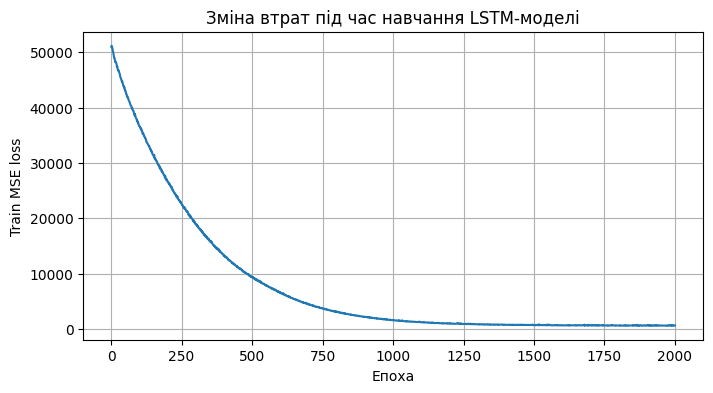

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_epochs + 1), losses)
plt.xlabel("Епоха")
plt.ylabel("Train MSE loss")
plt.title("Зміна втрат під час навчання LSTM-моделі")
plt.grid(True)
plt.show()

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

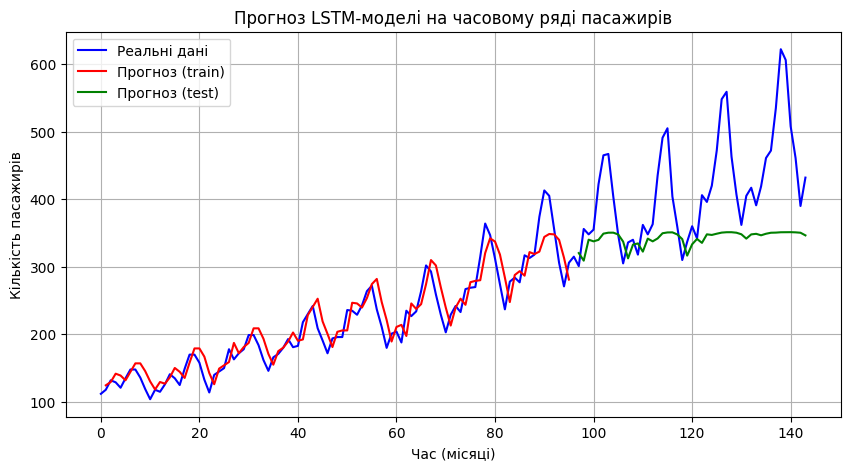

In [17]:
def plot_predicts():
    # timeseries — це наш оригінальний ряд passengers
    timeseries = passengers
    lookback = 1
    train_size = len(train_data)

    with torch.no_grad():
        # Прогнози для train
        train_plot = np.ones_like(timeseries) * np.nan
        y_pred_train = model(X_train).detach().numpy().flatten()
        train_plot[lookback:train_size] = y_pred_train

        # Прогнози для test
        test_plot = np.ones_like(timeseries) * np.nan
        y_pred_test = model(X_test).detach().numpy().flatten()
        test_plot[train_size + lookback:] = y_pred_test

    # Візуалізація
    plt.figure(figsize=(10, 5))
    plt.plot(timeseries, label='Реальні дані', color='blue')
    plt.plot(train_plot, label='Прогноз (train)', color='red')
    plt.plot(test_plot, label='Прогноз (test)', color='green')
    plt.title("Прогноз LSTM-моделі на часовому ряді пасажирів")
    plt.xlabel("Час (місяці)")
    plt.ylabel("Кількість пасажирів")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predicts()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [18]:
import torch
import torch.nn as nn

# --- 1. Створення моделі ---
model2 = AirModel(hidden_size=100, num_layers=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)

n_epochs = 2000
losses2 = []

# --- 2. Навчання ---
for epoch in range(n_epochs):
    model2.train()
    batch_losses = []

    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model2(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    losses2.append(epoch_loss)

    if (epoch + 1) % 100 == 0:
        model2.eval()
        with torch.no_grad():
            train_pred = model2(X_train)
            train_rmse = (criterion(train_pred, y_train).item())**0.5
            test_pred = model2(X_test)
            test_rmse = (criterion(test_pred, y_test).item())**0.5
        print(f"Epoch {epoch+1}: train RMSE={train_rmse:.4f}, test RMSE={test_rmse:.4f}")


Epoch 100: train RMSE=146.6736, test RMSE=337.9763
Epoch 200: train RMSE=97.8837, test RMSE=278.9027
Epoch 300: train RMSE=68.6630, test RMSE=234.8384
Epoch 400: train RMSE=48.9935, test RMSE=198.0725
Epoch 500: train RMSE=37.0752, test RMSE=169.1325
Epoch 600: train RMSE=32.5978, test RMSE=147.1705
Epoch 700: train RMSE=26.8267, test RMSE=129.0138
Epoch 800: train RMSE=26.4698, test RMSE=116.0961
Epoch 900: train RMSE=24.0649, test RMSE=108.1427
Epoch 1000: train RMSE=23.5730, test RMSE=102.4666
Epoch 1100: train RMSE=25.0735, test RMSE=99.2784
Epoch 1200: train RMSE=23.1586, test RMSE=94.4578
Epoch 1300: train RMSE=23.2665, test RMSE=92.8363
Epoch 1400: train RMSE=23.9009, test RMSE=91.4883
Epoch 1500: train RMSE=24.5143, test RMSE=91.6474
Epoch 1600: train RMSE=22.9913, test RMSE=88.4347
Epoch 1700: train RMSE=22.9538, test RMSE=87.4996
Epoch 1800: train RMSE=22.8860, test RMSE=85.7057
Epoch 1900: train RMSE=23.2952, test RMSE=84.1806
Epoch 2000: train RMSE=24.4292, test RMSE=83.553

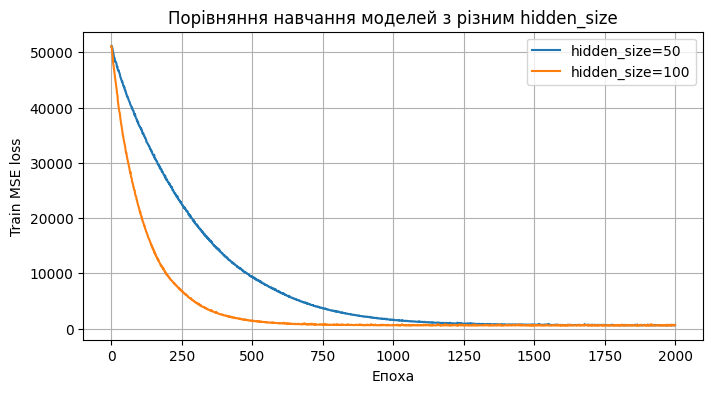

In [19]:
plt.figure(figsize=(8,4))
plt.plot(losses, label='hidden_size=50')
plt.plot(losses2, label='hidden_size=100')
plt.xlabel("Епоха")
plt.ylabel("Train MSE loss")
plt.title("Порівняння навчання моделей з різним hidden_size")
plt.legend()
plt.grid(True)
plt.show()

Після навчання LSTM-моделі з hidden_size = 50 на 2000 епох train-MSE стабільно зменшувався, що видно з графіка лосів. Це означає, що модель дійсно навчилась відтворювати структуру тренувальних даних.
Однак значення RMSE на тестовій вибірці залишилось досить великим (близько 100), тобто середня похибка прогнозу складає приблизно 80–100 пасажирів. На графіку прогнозів видно, що:

на train (червона лінія) модель доволі добре повторює реальний ряд (синя лінія);

на test (зелена лінія) модель передає загальний тренд, але гірше відтворює піки та спади, прогноз виходить більш “згладженим”.

Після збільшення розміру прихованого шару до hidden_size = 100 модель стала потужнішою, і це покращило якість:

test-RMSE зменшився приблизно з 101.9 до 83.6;

графік навчання показує нижчі значення MSE протягом епох;

модель краще підлаштовується під дані й дає точніші прогнози на тестовій вибірці.

Отже, можна зробити такі висновки:

LSTM-модель успішно навчилась ловити загальний тренд часових рядів пасажирів.

Модель з більшим hidden_size = 100 демонструє кращу якість прогнозу, ніж варіант із hidden_size = 50, хоча й є складнішою за кількістю параметрів.

Незважаючи на покращення, похибка на тестових даних все ще помітна, тому для більш точного прогнозу можна було б:

збільшити lookback (використовувати більше попередніх місяців для прогнозу),

масштабувати дані (наприклад, MinMaxScaler),

або спробувати більш глибоку архітектуру / регуляризацію.